In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pylab as plt
%matplotlib inline

In [4]:
data = pd.read_csv('africa_data')

In [9]:
events_year = data.groupby('year').size().reset_index(name='count')

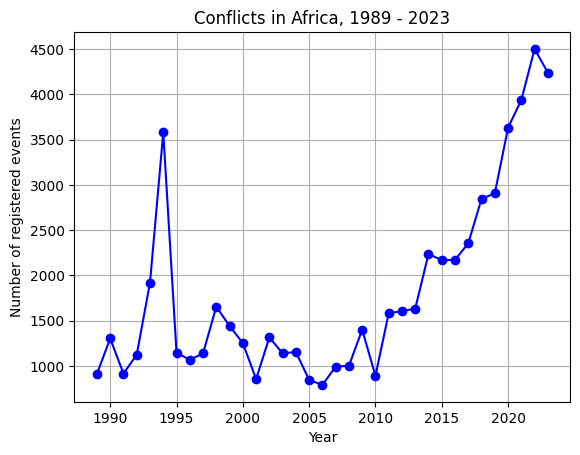

In [10]:
plt.plot(events_year['year'], events_year['count'], marker='o', color='b')
plt.title('Conflicts in Africa, 1989 - 2023')
plt.xlabel('Year')
plt.ylabel('Number of registered events')
plt.grid(True)
plt.show()

In [11]:
events_country = data['country'].value_counts()
events_country = events_country / events_country.sum() * 100

In [26]:
top_80 = events_country.sort_values(ascending=False).cumsum() <= 80
index = events_country.index.where(top_80, other = "Others")
events_country_grouped = events_country.groupby(index).sum()
events_country_grouped

country
Algeria                      6.564022
Angola                       3.296151
Burundi                      4.856245
Cameroon                     3.054203
Central African Republic     3.046347
DR Congo (Zaire)            12.686567
Ethiopia                     7.057345
Mali                         3.330715
Nigeria                     10.796544
Others                      20.158680
Rwanda                       4.087981
Somalia                     10.515318
South Africa                 4.545169
Sudan                        6.004713
Name: count, dtype: float64

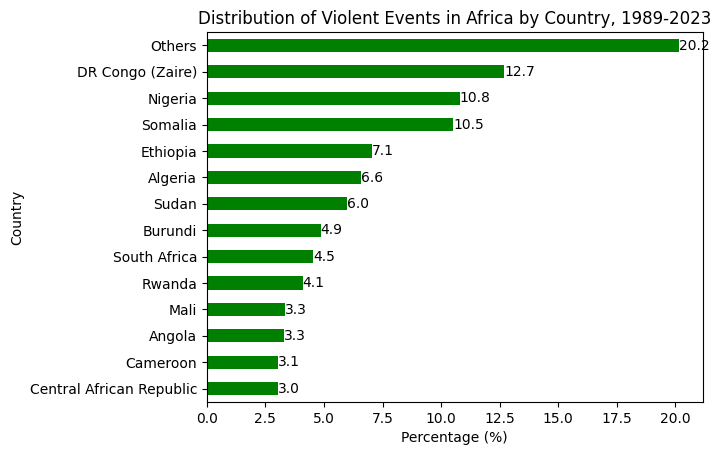

In [ ]:
ax = events_country_grouped.sort_values().plot(kind='barh', color='green')
plt.title('Distribution of Violent Events in Africa by Country, 1989-2023')
plt.xlabel('Percentage (%)')
plt.ylabel('Country')
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f')
plt.show()